In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Simplified 2D example(Real embeddings have hundreds of dimensions)
word_embeddings = {
    "cat":[0.8,0.6],
    "kitten":[0.75,0.65],
    "dog":[0.7,0.3],
    "puppy":[0.65,0.35],
    "car":[-0.5,0.2],
    "truck":[-0.45,0.15]
}

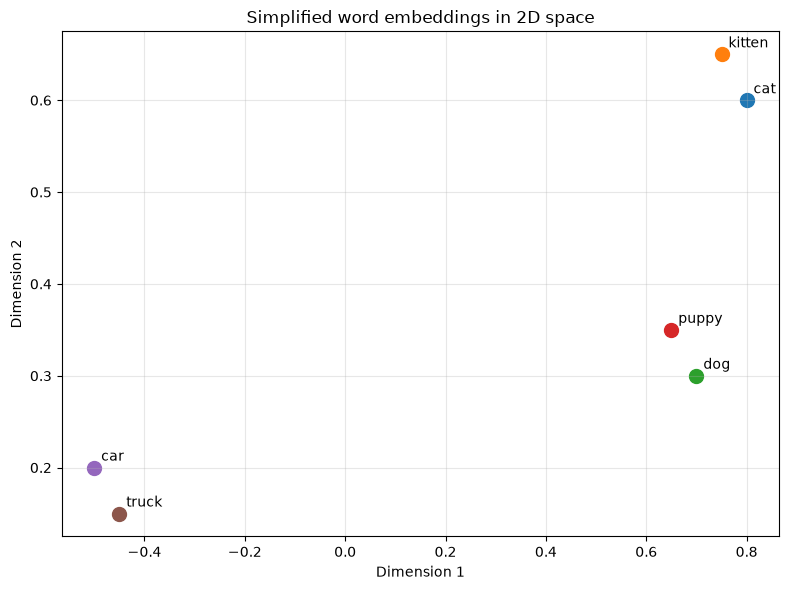

In [12]:
fig,ax = plt.subplots(figsize=(8,6))
for word,coords in word_embeddings.items():
    ax.scatter(coords[0],coords[1],s=100)
    ax.annotate(word,(coords[0],coords[1]),xytext=(5,5),
                textcoords='offset points')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_title('Simplified word embeddings in 2D space')
ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

### Measuring Similarity

In [13]:
def cosine_similarity(vec1,vec2):
    """
    - Result : close to 1 : Very similar
    - Result : close to 0 : Not related
    - Result : close to -1 : opposite
    """
    dot_product = np.dot(vec1,vec2)
    norm_a = np.linalg.norm(vec1)   # computes the norm (length/magnitude) of a vector or matrix.
    norm_b = np.linalg.norm(vec2)
    return dot_product/(norm_a*norm_b)

In [14]:
# Example
cat_vector = [0.8,0.6,0.3]
kitten_vector = [0.75,0.65,0.35]
car_vector = [-0.5,0.2,0.1]
cat_kitten_similarity = cosine_similarity(cat_vector,kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [ ]:
cosine_similarity(cat_vector,car_vector)

np.float64(-0.43718588548916804)

### Creating Embeddings

In [4]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)
embeddings

/tmp/ipykernel_532/801613826.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings
/tmp/ipykernel_532/801613826.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(client=SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
), model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, multi_process=False, show_progress=False)

In [5]:
### Create First Embeddings
text = "Hello, How are you? "
embedding = embeddings.embed_query(text) 
print(f"Text: {text}")  
print(f"Embedding length: {len(embedding)}")  
print(embedding) 

Text: Hello, How are you? 
Embedding length: 384
[0.019096706062555313, 0.03446515277028084, 0.09162794053554535, 0.07016528397798538, -0.029946601018309593, -0.08419138193130493, 0.04581361636519432, 0.00495854951441288, -0.09189335256814957, 0.017400657758116722, -0.008816185407340527, -0.0006614981102757156, -0.028556911274790764, -0.02194971777498722, 0.05516670271754265, -0.049836501479148865, 0.08988093584775925, -0.08895713090896606, -0.11235623061656952, 0.03900052234530449, -0.06607076525688171, 0.02609514817595482, 0.03653071075677872, 0.06139037385582924, -0.05712485685944557, -0.054639410227537155, 0.030365565791726112, 0.032387539744377136, 0.012644698843359947, -0.10568568855524063, -0.058345574885606766, 0.06732937693595886, -0.04075588285923004, 0.0064397407695651054, 0.005698626395314932, 0.05285323038697243, -0.03977523744106293, -0.11855248361825943, 0.002116201212629676, -0.016692863777279854, 0.028338080272078514, -0.037437960505485535, -0.02137141488492489, -0.041

In [6]:
sentences = [
    "The cat sat on the mat",
    "A feline rested on the rug",
    "The dog played on the yard",
    "I love python programming"
]

In [7]:
sentence_embeddings = embeddings.embed_documents(sentences)
sentence_embeddings

[[0.1304018199443817,
  -0.011870110407471657,
  -0.028117023408412933,
  0.051238641142845154,
  -0.05597442761063576,
  0.03019154816865921,
  0.03016132116317749,
  0.02469836361706257,
  -0.018370578065514565,
  0.05876681208610535,
  -0.024953193962574005,
  0.06015422195196152,
  0.039831776171922684,
  0.033230528235435486,
  -0.06131139397621155,
  -0.04937310889363289,
  -0.05486356094479561,
  -0.04007606953382492,
  0.056429095566272736,
  0.03915658965706825,
  -0.03473707661032677,
  -0.013247722759842873,
  0.03196622431278229,
  -0.06349920481443405,
  -0.06017858535051346,
  0.07823453098535538,
  -0.028303878381848335,
  -0.04744284972548485,
  0.04035930708050728,
  -0.0066309282556176186,
  -0.0667409896850586,
  -0.004191350191831589,
  -0.02531159669160843,
  0.05334164574742317,
  0.01742810197174549,
  -0.09792360663414001,
  0.006061304360628128,
  -0.06524161994457245,
  0.04557260498404503,
  0.023641837760806084,
  0.07658485323190689,
  -0.010264341719448566

In [15]:
### Calculate the similarity between all pairs
for i in range(len(sentences)):
    for j in range(i+1,len(sentences)):
        similarity = cosine_similarity(sentence_embeddings[i],sentence_embeddings[j])

        print(f"'{sentences[i]}' vs '{sentences[j]}'")
        print(f"Similarity: {similarity:.3f}\n")

'The cat sat on the mat' vs 'A feline rested on the rug'
Similarity: 0.564

'The cat sat on the mat' vs 'The dog played on the yard'
Similarity: 0.200

'The cat sat on the mat' vs 'I love python programming'
Similarity: 0.022

'A feline rested on the rug' vs 'The dog played on the yard'
Similarity: 0.290

'A feline rested on the rug' vs 'I love python programming'
Similarity: 0.071

'The dog played on the yard' vs 'I love python programming'
Similarity: 0.126



### Semantic Search

In [19]:
documents = [
    "Langchain is a famous framework",
    "The cat sat on the mat",
    "A feline rested on the rug",
    "The dog played on the yard",
    "I love python programming",
    "Python language is used for AI",
    "I love artifical intelligence",
    "I love dogs not cats"
]
query = "what is cat?"

In [17]:
def semantic_search(query,documents,embedding_models,top_k=3):
    # Simple semantic search implementation
    query_embedding = embedding_models.embed_query(query)
    doc_embeddings = embedding_models.embed_documents(documents)

    # calculate similarity score
    similarities = []

    for i,doc_emb in enumerate(doc_embeddings):
        similarity = cosine_similarity(query_embedding,doc_emb)
        similarities.append((similarity,documents[i]))

    similarities.sort(reverse=True)
    return similarities[:top_k]

In [20]:
results = semantic_search(query,documents,embeddings)
results

[(np.float64(0.5660475755438398), 'I love dogs not cats'),
 (np.float64(0.4934230334720931), 'The cat sat on the mat'),
 (np.float64(0.45122533083095473), 'A feline rested on the rug')]